In [30]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))
from algorithms.auxiliares import *
from algorithms.neural_network import *

In [31]:
class K_fold():
    def __init__(self, modelo, k):
        self.modelo = modelo
        self.k = k
        self.metrics = []
    
    def cross_val(self, X, y): # Recibe dataset completo
        N = X.shape[0]
        fold_size = N//self.k

        idx = np.arange(N)
        np.random.shuffle(idx)

        for i in range(self.k):
            idx_select = idx[i*fold_size : (i+1)*fold_size-1]

            mask = np.ones(N, dtype=bool)
            mask[idx_select] = False
            
            X_test, y_test = X[idx_select], y[idx_select].reshape(-1,1)
            X_train, y_train = X[mask], y[mask].reshape(-1,1)

            # Ahora si intercambiamos edades -1 por la media
            edad_media = np.mean(X_train[:,33])
            X_train[X_train[:,33] == -1] = edad_media
            X_test[X_test[:,33] == -1] = edad_media

            # Diferentes escalas de datos en features
            media = np.mean(X_train, axis=0)
            std = np.std(X_train, axis=0)
            X_train = (X_train - media) / std
            X_test = (X_test - media) / std

            self.modelo.fit(X_train, y_train)
            metrica = self.modelo.score(X_test, y_test)
            self.metrics.append(metrica)
            print(f"K={i}, Métrica: {metrica}")
            
            cm = self.modelo.confusion_matrix(X_test, y_test)
            print(cm)
            print("Sensibilidad:", cm[0,0]/(cm[0,0] + cm[0,1])) # SENSIBILIDAD

        return np.mean(self.metrics)


In [32]:
ruta_data = os.path.abspath('../data')

X, y = cargar_datos_csv(os.path.join(ruta_data, 'dermatology.csv'))

X = np.array(X)

# encontrar la moda
valores, counts = np.unique(y, return_counts=True)
moda = valores[np.argmax(counts)]

#print(X[0,:])

# construir array binario
y = (y == moda).astype(int).flatten()
y = 2*y - 1

#print(moda)  
#print(y)  

# El ganador fue psoriasis!!
# Hay 8 personas cuya edad tiene un '?', hice que al importar el dataset
# se ponga -1, así reemplazamos tras splittear con la media.

y = np.array(y)
print(X.shape, y.shape, np.mean(y))

(366, 34) (366,) -0.3879781420765027


In [33]:
model = neural_network(
    layers_config = [(5, 'symmetry sigmoid'), (5, 'symmetry sigmoid'), (1, 'symmetry sigmoid')],
    size_input=X.shape[1],
    max_epoch = 300,
    learning_rate=0.01,
    error_threshold=1e-3
)

k_fold = K_fold(model, k=5)

print(k_fold.cross_val(X,y))

K=0, Métrica: 1.0
[[52.  0.]
 [ 0. 20.]]
Sensibilidad: 1.0
K=1, Métrica: 0.9861111111111112
[[54.  0.]
 [ 1. 17.]]
Sensibilidad: 1.0
K=2, Métrica: 1.0
[[50.  0.]
 [ 0. 22.]]
Sensibilidad: 1.0
K=3, Métrica: 1.0
[[47.  0.]
 [ 0. 25.]]
Sensibilidad: 1.0
K=4, Métrica: 1.0
[[50.  0.]
 [ 0. 22.]]
Sensibilidad: 1.0
0.9972222222222221


In [34]:
N = X.shape[0]

idx = np.arange(N)
np.random.shuffle(idx)

idx_select = idx[0:297]

mask = np.ones(N, dtype=bool)
mask[idx_select] = False

X_test, y_test = X[idx_select], y[idx_select].reshape(-1,1)
X_train, y_train = X[mask], y[mask].reshape(-1,1)

# Diferentes escalas de datos en features
media = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
X_train = (X_train - media) / std
X_test = (X_test - media) / std


In [35]:
model = neural_network(
    layers_config = [(10, 'symmetry sigmoid'), (10, 'symmetry sigmoid'), (1, 'symmetry sigmoid')],
    size_input=X.shape[1],
    max_epoch = 300,
    learning_rate=0.01,
    error_threshold=1e-3
)

model.fit(X_train, y_train)
y_pred = model.transform(X_test)

print(model.score(X_test, y_test))
print(model.confusion_matrix(X_test, y_test))

0.9966329966329966
[[207.   1.]
 [  0.  89.]]


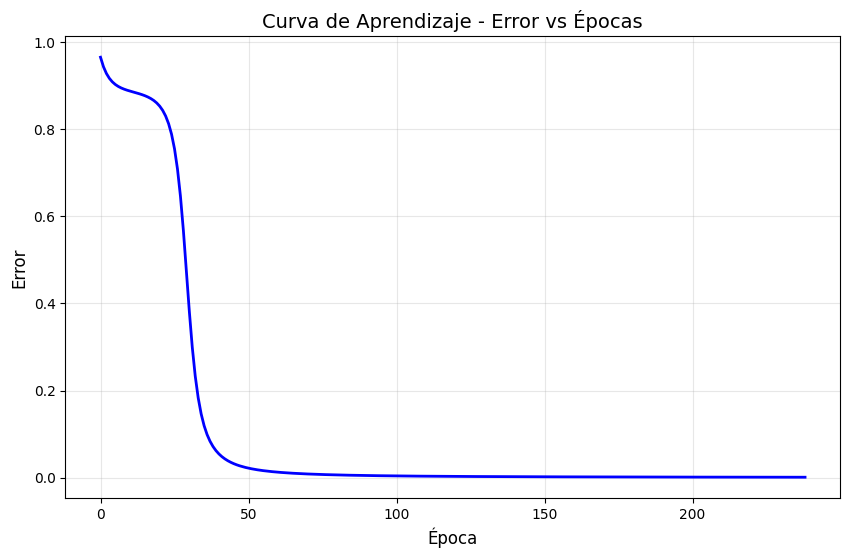

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(model.epoch_error, color='blue', linewidth=2)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Curva de Aprendizaje - Error vs Épocas', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()